# 1. Importações

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Tratamento

### 2.1 Exclusão por Variáveis Qualitativas Críticas

In [28]:
df_raw = pd.read_csv("dataset.csv", sep=";", low_memory=False)
print(f"Dimensões originais do dataset: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas\n")

# Remove observações com nulos nas variáveis vitais de categorização.
critical_cols = ['Data_da_Ocorrencia', 'Classificacao_da_Ocorrencia', 'Operacao']
df_clean = df_raw.dropna(subset=critical_cols).copy()

Dimensões originais do dataset: 5021 linhas e 45 colunas



### 2.2 Extração e Filtragem Temporal

In [29]:
# Extraindo o ano a partir da coluna de data.
df_clean['Data_da_Ocorrencia'] = pd.to_datetime(df_clean['Data_da_Ocorrencia'], errors='coerce')
df_clean['ANO_OCORRENCIA'] = df_clean['Data_da_Ocorrencia'].dt.year

# Filtra os anos que fornecem dados mais consistentes.
df_clean = df_clean[(df_clean['ANO_OCORRENCIA'] >= 1998) & (df_clean['ANO_OCORRENCIA'] <= 2022)].copy()

print(f"Dimensões do dataset tratado: {df_clean.shape[0]} linhas\n")
df_clean.head()

Dimensões do dataset tratado: 4441 linhas



,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO,ANO_OCORRENCIA
0,5015,/2005,JOSE SEVERINO ENEAS CANDIDO,Acidente,2005-03-27,NaN,NaN,CE,Nordeste,NaN,...,0.0,0.0,EMB-720C,L1P,PA32,1542.0,7.0,NEIVA,verdadeiro,2005
1,5014,/2005,STILUS TAXI AEREO LTDA,Acidente,2005-03-19,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,EMB-721C,L1P,P32R,1633.0,7.0,NEIVA,verdadeiro,2005
2,5013,/2005,AGROPENA AVIACAO AGRICOLA LTDA,Acidente,2005-03-18,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,PA-25-260,L1P,PA25,1315.0,1.0,PIPER AIRCRAFT,verdadeiro,2005
3,5023,/2005,LEONARDO SUBTIL MARTINS ALMEIDA,Acidente,2005-05-27,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,140A,L1P,C140,680.0,2.0,CESSNA AIRCRAFT,verdadeiro,2005
4,5012,/2005,MARISA MENDES DE OLIVEIRA,Acidente,2005-03-18,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,172,L1P,C172,998.0,4.0,CESSNA AIRCRAFT,verdadeiro,2005


### 2.3 Agrupamento de Segmento de Aviação

In [30]:
# Identifica os 4 maiores segmentos
critical_sectors = ['Voo Privado', 'Operação Agrícola', 'Voo de Instrução', 'Táxi Aéreo']
# Tudo o que não for top 4 vira "Outros Segmentos"
df_clean['SEGMENTO_AGRUPADO'] = df_clean['Operacao'].apply(
    lambda x: x if x in critical_sectors else 'Outros Segmentos'
)

### 2.4 Imputação e Agrupamento das Lesões

In [31]:
colunas_fatais = ['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros']
colunas_graves = ['Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros']
colunas_leves  = ['Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros', 'Lesoes_Leves_Terceiros']

# Imputação com zero
todas_colunas_lesoes = colunas_fatais + colunas_graves + colunas_leves
for col in todas_colunas_lesoes:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
    else:
        df_clean[col] = 0

# Criação das métricas globais agregadas
df_clean['TOTAL_FATALIDADES'] = df_clean[colunas_fatais].sum(axis=1)
df_clean['TOTAL_LESOES']  = df_clean[colunas_graves].sum(axis=1) + df_clean[colunas_leves].sum(axis=1)

### 2.5 Filtragem do Peso Máximo de Decolagem

In [32]:
df_clean['PMD'] = pd.to_numeric(df_clean['PMD'], errors='coerce')

n_before = len(df_clean)

df_clean = df_clean[df_clean['PMD'] > 0].copy()

n_after = len(df_clean)
print(f"--> [Metodologia] Removidos {n_before - n_after} registros com PMD inválido.")
print(f"--> [Amostra Consolidada] Novo tamanho estável da base (N) = {n_after} registros.\n")

--> [Metodologia] Removidos 140 registros com PMD inválido.
--> [Amostra Consolidada] Novo tamanho estável da base (N) = 4301 registros.



# 3. Análise Unidimensional Qualitativa

### 3.1 Distribuição de Frequência para Classificação da Ocorrência

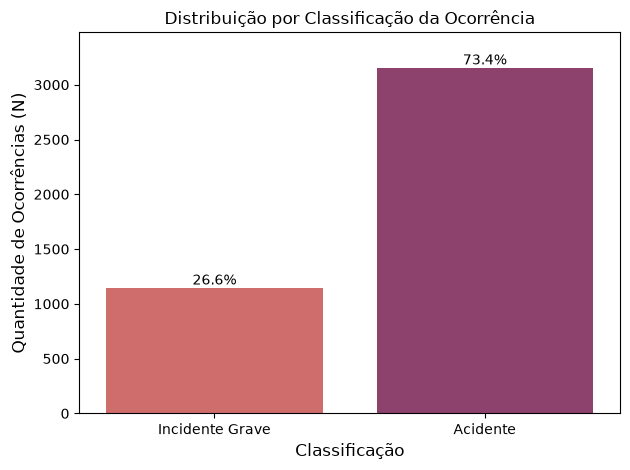

In [33]:
fig, ax = plt.subplots()

order = (
    df_clean['Classificacao_da_Ocorrencia']
    .value_counts()
    .sort_values()
    .index
)
sns.countplot(data=df_clean, 
            x='Classificacao_da_Ocorrencia', 
            hue='Classificacao_da_Ocorrencia',
            order=order, 
            palette='flare_r', 
            legend=False, 
            ax=ax)
ax.set_title('Distribuição por Classificação da Ocorrência')
ax.set_xlabel('Classificação', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências (N)', fontsize=12)

ax.set_ylim(top=ax.get_ylim()[1] * 1.05)
length = len(df_clean)
for bar in ax.patches:
    height = bar.get_height()
    percent = 100 * height / length
    ax.annotate(
        f'{percent:.1f}%',
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

### 3.2 Distribuição de Frequência para Segmento de Aviação

In [34]:
freq_seg_abs = df_clean['Operacao'].value_counts()
freq_seg_rel = df_clean['Operacao'].value_counts(normalize=True) * 100

tab_segmento = pd.DataFrame({
    'Frequência Absoluta (N)': freq_seg_abs,
    'Frequência Relativa (%)': freq_seg_rel
})
print(tab_segmento.round(2))
print("\n" + "="*50 + "\n")

                        Frequência Absoluta (N)  Frequência Relativa (%)
Operacao                                                                
Voo Privado                                1956                    45.48
Operação Agrícola                           747                    17.37
Voo de Instrução                            704                    16.37
Táxi Aéreo                                  488                    11.35
Voo Regular                                 129                     3.00
Operação Pública                            119                     2.77
Operação Especializada                       98                     2.28
Voo Experimental                             38                     0.88
Voo não regular                               8                     0.19
Operação Policial                             8                     0.19
Desconhecida                                  6                     0.14




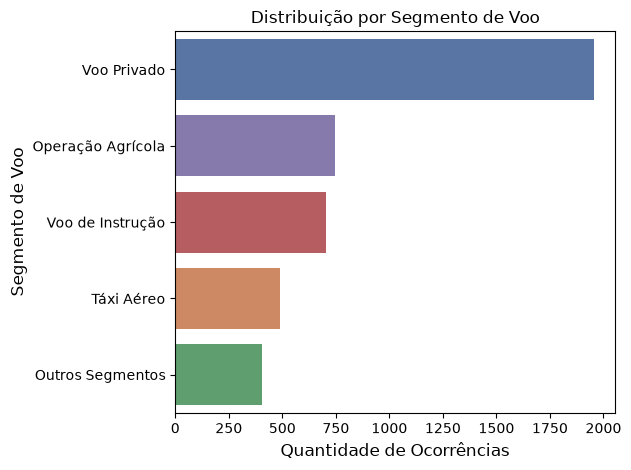

In [35]:
fig, ax = plt.subplots()

segmentos = df_clean['SEGMENTO_AGRUPADO'].value_counts().index
sns.countplot(data=df_clean,
              y='SEGMENTO_AGRUPADO', hue='SEGMENTO_AGRUPADO', palette='deep', order=segmentos, legend=False)

ax.set_title('Distribuição por Segmento de Voo')
ax.set_xlabel('Quantidade de Ocorrências', fontsize=12)
ax.set_ylabel('Segmento de Voo', fontsize=12)

plt.tight_layout()
plt.show()

### 3.3 Evolução Temporal

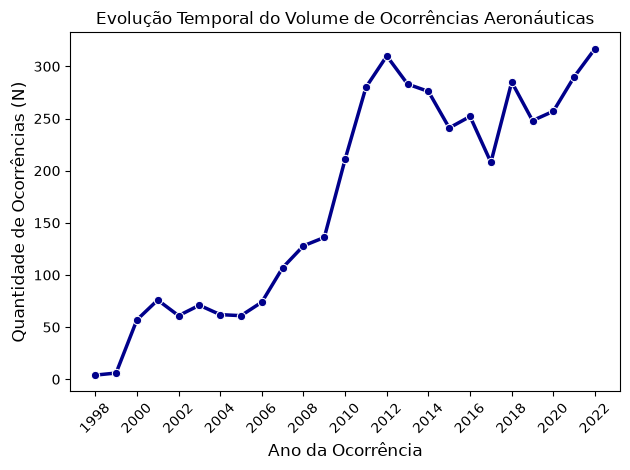

In [36]:
fig, ax = plt.subplots()
freq_year_abs = df_clean['ANO_OCORRENCIA'].value_counts().sort_index()
sns.lineplot(x=freq_year_abs.index, 
             y=freq_year_abs.values, 
             marker='o', 
             color='darkblue', 
             linewidth=2.5, 
             ax=ax)

ax.set_title('Evolução Temporal do Volume de Ocorrências Aeronáuticas')
ax.set_xlabel('Ano da Ocorrência', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências (N)', fontsize=12)

plt.xticks(range(1998, 2023, 2), rotation=45)
plt.tight_layout()
plt.show()

# 4. Análise Unidimensional Quantitativa

In [37]:
print("="*60)
print("ESTATÍSTICA DESCRITIVA UNIDIMENSIONAL - BASE CONSOLIDADA")
print("="*60)

print(f"\n[Métricas: PMD (kg)] | N = {len(df_clean)}")
print(df_clean['PMD'].describe())
print(f"median        {df_clean['PMD'].median():.2f}")

print(f"\n[Métricas: TOTAL_LESOES] | N = {len(df_clean)}")
print(df_clean['TOTAL_LESOES'].describe())
print(f"median        {df_clean['TOTAL_LESOES'].median():.2f}")

print(f"\n[Métricas: TOTAL_FATALIDADES] | N = {len(df_clean)}")
print(df_clean['TOTAL_FATALIDADES'].describe())
print(f"median        {df_clean['TOTAL_FATALIDADES'].median():.2f}")

ESTATÍSTICA DESCRITIVA UNIDIMENSIONAL - BASE CONSOLIDADA

[Métricas: PMD (kg)] | N = 4301
count      4301.000000
mean       3668.135085
std       13910.435012
min          35.000000
25%        1000.000000
50%        1633.000000
75%        2155.000000
max      346544.000000
Name: PMD, dtype: float64
median        1633.00

[Métricas: TOTAL_LESOES] | N = 4301
count    4301.000000
mean        0.386422
std         1.062661
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        23.000000
Name: TOTAL_LESOES, dtype: float64
median        0.00

[Métricas: TOTAL_FATALIDADES] | N = 4301
count    4301.000000
mean        0.444780
std         4.026255
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       199.000000
Name: TOTAL_FATALIDADES, dtype: float64
median        0.00


### 4.1 Distribuição de PMD

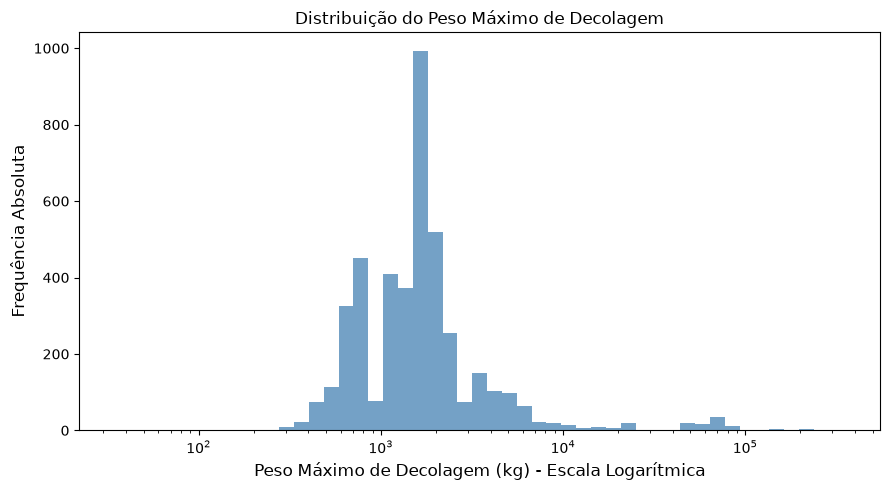

Coeficiente de Assimetria (Dados Originais): 11.95
Coeficiente de Assimetria (Escala Logarítmica): 1.89


In [38]:
plt.figure(figsize=(9, 5))
bins_log = np.logspace(np.log10(df_clean['PMD'].min()), 
                        np.log10(df_clean['PMD'].max()), 50)

sns.histplot(data=df_clean, x='PMD', bins=bins_log, color='steelblue')
plt.xscale('log')
plt.title('Distribuição do Peso Máximo de Decolagem')
plt.xlabel('Peso Máximo de Decolagem (kg) - Escala Logarítmica', fontsize=12)
plt.ylabel('Frequência Absoluta', fontsize=12)

plt.tight_layout()
plt.show()

# Assimetria dos dados originais (em kg)
skewness_original = df_clean['PMD'].skew()

# Assimetria dos dados na escala logarítmica (em kg)
skewness_log = np.log10(df_clean['PMD']).skew()

print(f"Coeficiente de Assimetria (Dados Originais): {skewness_original:.2f}")
print(f"Coeficiente de Assimetria (Escala Logarítmica): {skewness_log:.2f}")

### 4.2 Distribuição dos Danos Humanos

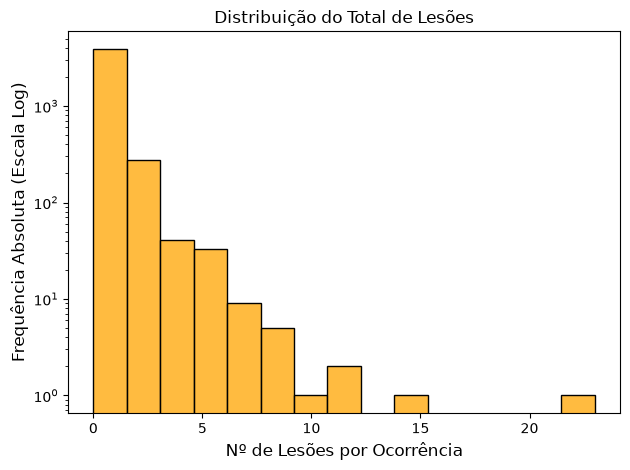

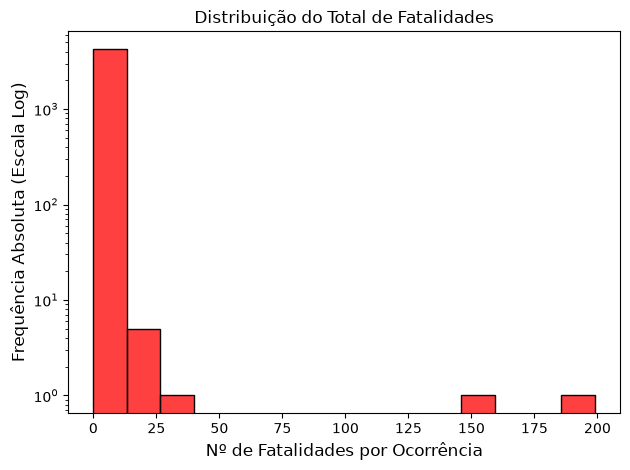

Coeficiente de assimetria de LESOES: 6.220
Coeficiente de assimetria de FATALIDADES: 41.111


In [39]:
fig, ax = plt.subplots()
sns.histplot(data=df_clean, 
             x='TOTAL_LESOES', 
             kde=False, 
             bins=15, 
             ax=ax, 
             color='orange')
ax.set_title('Distribuição do Total de Lesões')
ax.set_xlabel('Nº de Lesões por Ocorrência', fontsize=12)
ax.set_ylabel('Frequência Absoluta (Escala Log)', fontsize=12)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
sns.histplot(data=df_clean, 
             x='TOTAL_FATALIDADES', 
             kde=False, 
             bins=15, 
             ax=ax, 
             color='red')
ax.set_title('Distribuição do Total de Fatalidades')
ax.set_xlabel('Nº de Fatalidades por Ocorrência', fontsize=12)
ax.set_ylabel('Frequência Absoluta (Escala Log)', fontsize=12)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"Coeficiente de assimetria de LESOES: {df_clean['TOTAL_LESOES'].skew():.3f}")
print(f"Coeficiente de assimetria de FATALIDADES: {df_clean['TOTAL_FATALIDADES'].skew():.3f}")

# 5. Análise Bidimensional

### 5.1 Segmento de Aviação VS Classificação

--- CRUZAMENTO: SEGMENTO DE AVIAÇÃO VS CLASSIFICAÇÃO ---

% de Gravidade dentro de cada Segmento de Voo:
Classificacao_da_Ocorrencia  Acidente  Incidente Grave
Operacao                                              
Voo não regular                 25.00            75.00
Voo Regular                     41.09            58.91
Operação Policial               62.50            37.50
Voo de Instrução                64.77            35.23
Operação Pública                65.55            34.45
Voo Experimental                68.42            31.58
Táxi Aéreo                      69.26            30.74
Voo Privado                     74.64            25.36
Operação Agrícola               85.94            14.06
Operação Especializada          90.82             9.18
Desconhecida                   100.00             0.00


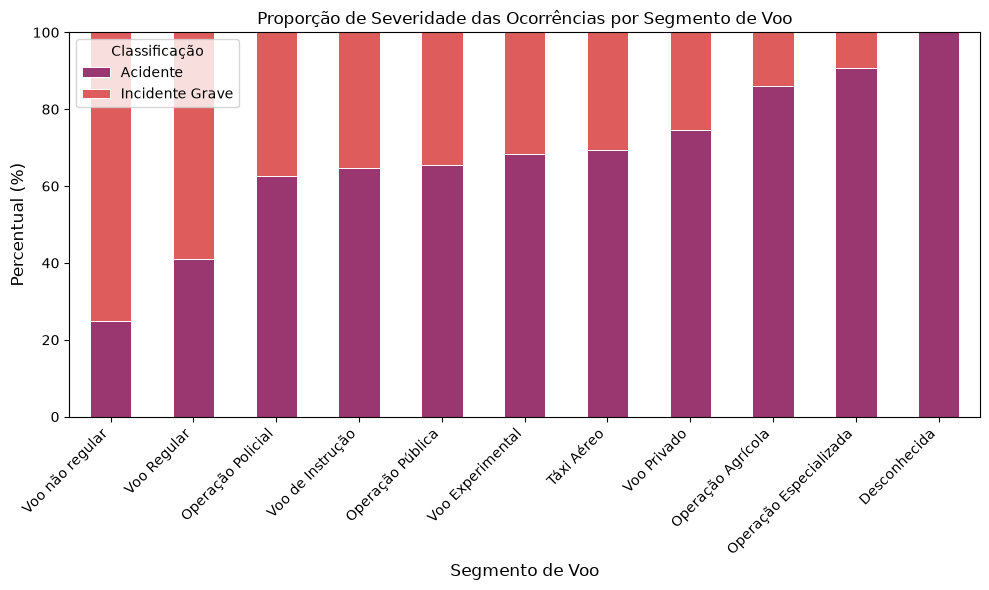

In [40]:
print("--- CRUZAMENTO: SEGMENTO DE AVIAÇÃO VS CLASSIFICAÇÃO ---")
tab_segmento_gravidade = pd.crosstab(
    df_clean['Operacao'], 
    df_clean['Classificacao_da_Ocorrencia'], 
    normalize='index') * 100
tab_segmento_gravidade = tab_segmento_gravidade.sort_values(by='Acidente', ascending=True)
print("\n% de Gravidade dentro de cada Segmento de Voo:")
print(tab_segmento_gravidade.round(2))

cores_hierarquia = sns.color_palette("flare_r", n_colors=2)
ax = tab_segmento_gravidade.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=cores_hierarquia,
    edgecolor='white',
    linewidth=0.7,)
plt.title('Proporção de Severidade das Ocorrências por Segmento de Voo')
plt.xlabel('Segmento de Voo', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

### 5.2 PMD VS Classificação

                              count     mean       std    min     25%     50%  \
Classificacao_da_Ocorrencia                                                     
Acidente                     3155.0  2910.44  12304.78   35.0  1043.0  1633.0   
Incidente Grave              1146.0  5754.11  17426.42  380.0   902.5  1800.0   

                                75%       max  
Classificacao_da_Ocorrencia                    
Acidente                     1996.0  280320.0  
Incidente Grave              2449.0  346544.0  


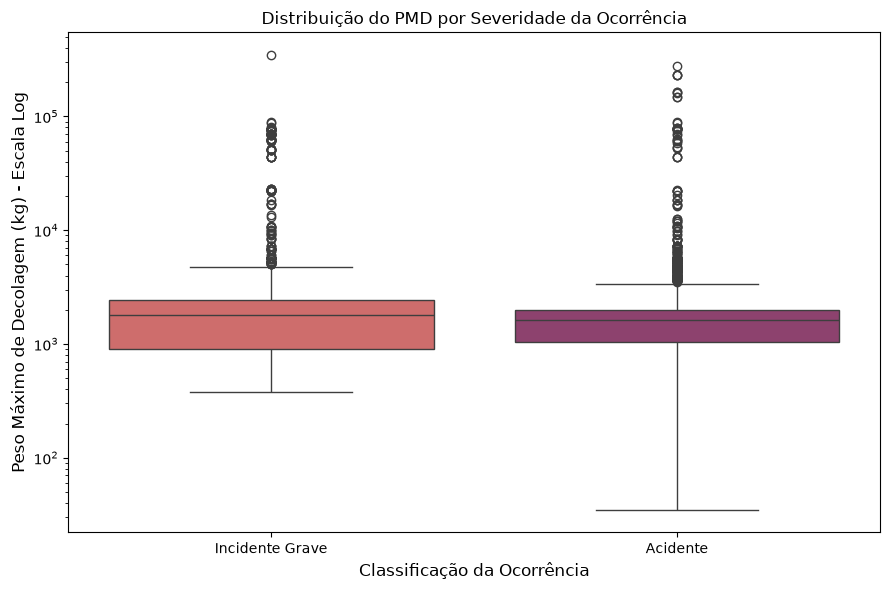

In [41]:
print(df_clean.groupby('Classificacao_da_Ocorrencia')['PMD'].describe().round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_clean, 
            x='Classificacao_da_Ocorrencia', 
            y='PMD',
            hue='Classificacao_da_Ocorrencia',
            order=['Incidente Grave', 'Acidente'],
            hue_order=['Incidente Grave', 'Acidente'], 
            palette='flare')
plt.yscale('log')
plt.title('Distribuição do PMD por Severidade da Ocorrência')
plt.xlabel('Classificação da Ocorrência', fontsize=12)
plt.ylabel('Peso Máximo de Decolagem (kg) - Escala Log', fontsize=12)

plt.tight_layout()
plt.show()

### 5.4 Letalidade Humana vs. Segmento de Voo

--- METRICAS DE DANOS HUMANOS POR SEGMENTO DE AVIAÇÃO ---
                       TOTAL_FATALIDADES               TOTAL_LESOES         \
                                     sum   mean    max          sum   mean   
Operacao                                                                     
Desconhecida                         2.0  0.333    2.0          1.0  0.167   
Operação Agrícola                  128.0  0.171    6.0        180.0  0.241   
Operação Especializada              35.0  0.357    2.0         67.0  0.684   
Operação Policial                    2.0  0.250    1.0         12.0  1.500   
Operação Pública                    43.0  0.361    8.0         73.0  0.613   
Táxi Aéreo                         231.0  0.473   24.0        268.0  0.549   
Voo Experimental                    16.0  0.421    3.0         10.0  0.263   
Voo Privado                        931.0  0.476   14.0        771.0  0.394   
Voo Regular                        448.0  3.473  199.0         95.0  0.736   
Voo de

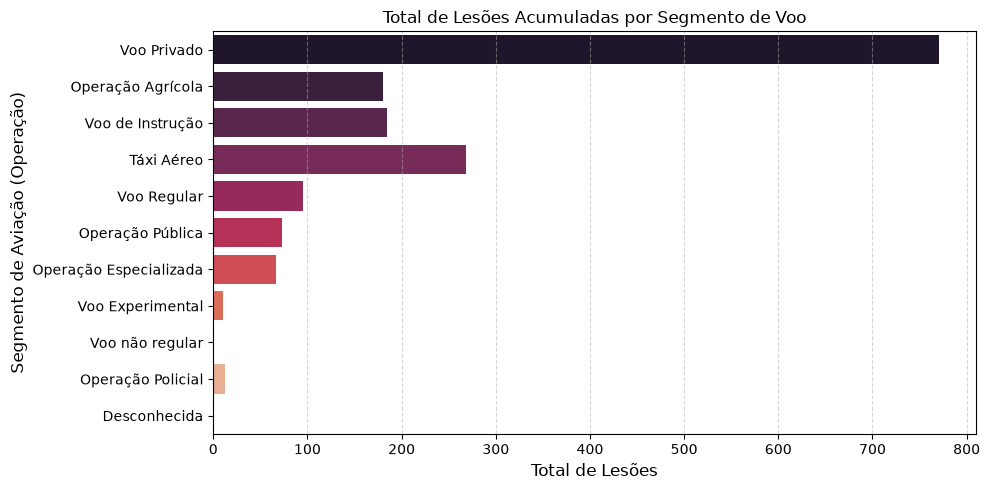

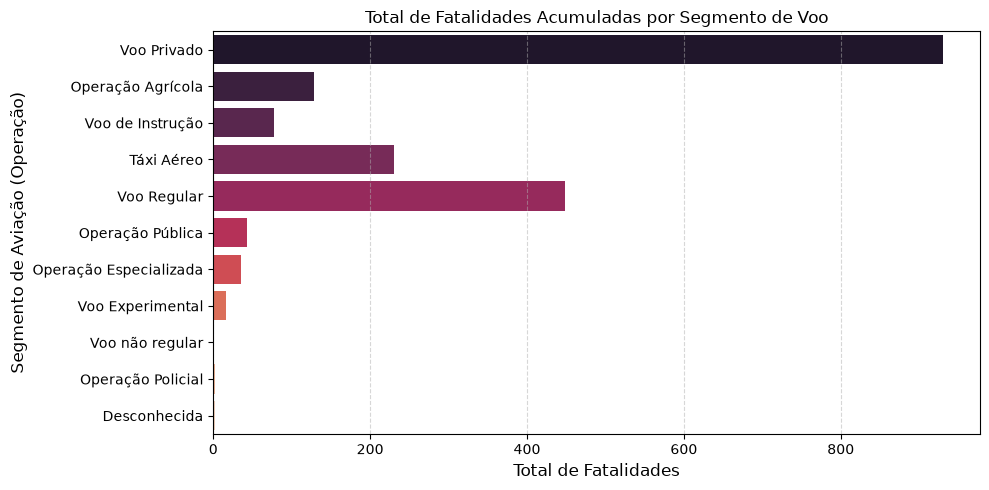

In [42]:
ordem_operacao = [
    'Voo Privado', 'Operação Agrícola', 'Voo de Instrução', 'Táxi Aéreo',
    'Voo Regular', 'Operação Pública', 'Operação Especializada',
    'Voo Experimental', 'Voo não regular', 'Operação Policial', 'Desconhecida'
]

dados_humanos_segmento = df_clean.groupby('Operacao')[['TOTAL_FATALIDADES', 'TOTAL_LESOES']].agg(['sum', 'mean', 'max'])
print("--- METRICAS DE DANOS HUMANOS POR SEGMENTO DE AVIAÇÃO ---")
print(dados_humanos_segmento.round(3))

df_lesoes = df_clean.groupby('Operacao')['TOTAL_LESOES'].sum().reset_index()
df_fatalidades = df_clean.groupby('Operacao')['TOTAL_FATALIDADES'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_lesoes, 
    x='TOTAL_LESOES', 
    y='Operacao', 
    palette='rocket',
    hue='Operacao',
    order=ordem_operacao,  
    hue_order=ordem_operacao, 
    legend=False
)
plt.title('Total de Lesões Acumuladas por Segmento de Voo', fontsize=12)
plt.xlabel('Total de Lesões', fontsize=12)
plt.ylabel('Segmento de Aviação (Operação)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_fatalidades, 
    x='TOTAL_FATALIDADES', 
    y='Operacao', 
    palette='rocket',
    hue='Operacao',
    order=ordem_operacao,
    hue_order=ordem_operacao,
    legend=False
)
plt.title('Total de Fatalidades Acumuladas por Segmento de Voo', fontsize=12)
plt.xlabel('Total de Fatalidades', fontsize=12)
plt.ylabel('Segmento de Aviação (Operação)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()